In [1]:
import pandas as pd
from stock_data_analyser import *

In [7]:
sda= StockDataAnalyser(stock_symbol='MSFT')
sda.fetch_and_store_stock_data(mode='sql')

2025-04-16 10:23:11 - StockDataAnalyser - INFO - Fetching stock data for MSFT...
2025-04-16 10:23:11 - StockDataScraper - INFO - Fetching stock data for MSFT...
2025-04-16 10:23:14 - StockDataScraper - INFO - Fetched stock data for MSFT successfully...
2025-04-16 10:23:14 - StockDataAnalyser - INFO - Saved stock data to sql


,Open,High,Low,Close,Volume,EMA,Bollinger_Upper,Bollinger_Lower,Close_Lag1,Close_Lag2,...,Close_Lag12,Close_Lag13,Close_Lag14,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19,Trend,Stock_name
2025-03-18,387.070,387.3700,381.1000,383.52,19486850,384.445883,405.269889,357.752111,388.70,388.56,...,396.99,392.53,399.73,397.90,404.00,408.21,416.13,414.77,NaN,MSFT
2025-03-17,386.700,392.7050,385.5700,388.70,22474272,384.851037,405.367339,357.743661,388.56,378.77,...,392.53,399.73,397.90,404.00,408.21,416.13,414.77,409.64,NaN,MSFT
2025-03-14,379.775,390.2300,379.5100,388.56,19952846,385.204272,405.379594,357.742406,378.77,383.27,...,399.73,397.90,404.00,408.21,416.13,414.77,409.64,408.43,NaN,MSFT
2025-03-13,383.155,385.3200,377.4500,378.77,20473017,384.591484,405.283330,357.580670,383.27,380.45,...,397.90,404.00,408.21,416.13,414.77,409.64,408.43,410.54,NaN,MSFT
2025-03-12,382.950,385.2165,378.9507,383.27,24253567,384.465628,404.560897,357.581103,380.45,380.16,...,404.00,408.21,416.13,414.77,409.64,408.43,410.54,409.04,NaN,MSFT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-29,255.460,256.1000,249.0000,252.51,40589023,249.525190,255.433368,239.927632,254.56,261.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MSFT
2021-04-28,256.078,256.5399,252.9500,254.56,46903119,250.004696,256.014234,239.653766,261.97,261.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MSFT
2021-04-27,261.585,263.1900,260.1200,261.97,31014213,251.144249,258.578796,238.114204,261.55,261.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MSFT
2021-04-26,261.660,262.4350,260.1700,261.55,19763346,252.135273,260.672016,237.097984,261.15,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MSFT


In [8]:
df=sda.stock_data


In [4]:
# # df['Close_Lead1'] = df['Close'].shift(-10)
# for i in range(1,5):
#     df[f"Close_Lead{i}"] = df['Close'].shift(-i)
# df.dropna(inplace=True)


In [9]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'EMA', 'Bollinger_Upper',
       'Bollinger_Lower', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3',
       'Close_Lag4', 'Close_Lag5', 'Close_Lag6', 'Close_Lag7', 'Close_Lag8',
       'Close_Lag9', 'Close_Lag10', 'Close_Lag11', 'Close_Lag12',
       'Close_Lag13', 'Close_Lag14', 'Close_Lag15', 'Close_Lag16',
       'Close_Lag17', 'Close_Lag18', 'Close_Lag19', 'Trend', 'Stock_name'],
      dtype='object')

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow import keras
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


2025-04-16 10:24:27.159146: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 10:24:27.183049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744779267.197729   33125 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744779267.202554   33125 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744779267.215599   33125 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [15]:
# Drop non-numeric and target column from features
'''
        'Close_Lag1', 'Close_Lag2',
       'Close_Lag3', 'Close_Lag4', 'Close_Lag5', 'Close_Lag6', 'Close_Lag7',
       'Close_Lag8', 'Close_Lag9', 'Close_Lag10', 'Close_Lag11', 'Close_Lag12',
       'Close_Lag13', 'Close_Lag14', 'Close_Lag15', 'Close_Lag16',
       'Close_Lag17', 'Close_Lag18', 'Close_Lag19', 
'''

# Define input (X) and target (y)
y = df['Close'].values  # Target variable
X = df.drop(columns=['Open', 'High', 'Low', 'Volume', 'EMA','Close', 'Bollinger_Upper','Bollinger_Lower', 'Trend', 'Stock_name']).values  # Features


In [16]:
y.shape, X.shape


((980,), (980, 19))

In [35]:

# Normalize features
scalerX = StandardScaler()
scalerY = StandardScaler()
# X = scalerX.fit_transform(X)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
# X_train = scalerX.fit_transform(X_train)
# X_test = scalerX.transform(X_test)
# y_train = scalerY.fit_transform(y_train.reshape(-1, 1))
# y_test = scalerY.transform(y_test.reshape(-1, 1))
# xtrain_scaled = scalerX.fit_transform(X_train)
# xtest_scaled = scalerX.transform(X_test)


In [36]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape, type(X_train)

((784, 19), (196, 19), (784,), (196,), numpy.ndarray)

In [61]:
# # Define the neural network model
model = keras.Sequential([
    # keras.layers.Dense(256, activation='relu', input_shape=(X.shape[1],)),  
    keras.layers.LSTM(256, return_sequences=True, input_shape=(X.shape[1],)),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Output layer for regression (no activation)
])
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense

# model = Sequential()
# model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
# model.add(LSTM(50, return_sequences=True))
# model.add(LSTM(50))
# model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# from tensorflow.keras.optimizers import Adam
# model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Increase epochs
EPOCHS = 100

# Train the model with callbacks
model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[ checkpoint]
)


# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.2f}")

ValueError: Input 0 of layer "lstm_9" is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (None, 19)

In [43]:
import matplotlib.pyplot as plt

# Get predictions
# y_train_pred = scalerY.inverse_transform(model.predict(X_train))
# y_test_pred = scalerY.inverse_transform(model.predict(X_test))
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
y_train = y_train
y_test = y_test



25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [44]:
X_train

array([[421.9 , 427.93, 423.26, ..., 425.23, 421.41, 417.32],
       [318.27, 314.98, 314.27, ..., 319.91, 323.8 , 324.9 ],
       [377.43, 377.85, 373.07, ..., 346.07, 338.11, 337.31],
       ...,
       [319.97, 327.  , 322.46, ..., 327.5 , 336.34, 335.92],
       [259.53, 254.25, 256.72, ..., 267.7 , 258.86, 253.13],
       [334.  , 333.13, 329.37, ..., 292.88, 294.23, 294.85]])

In [49]:
y_train_pred

array([[333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60345],
       [333.60345],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],


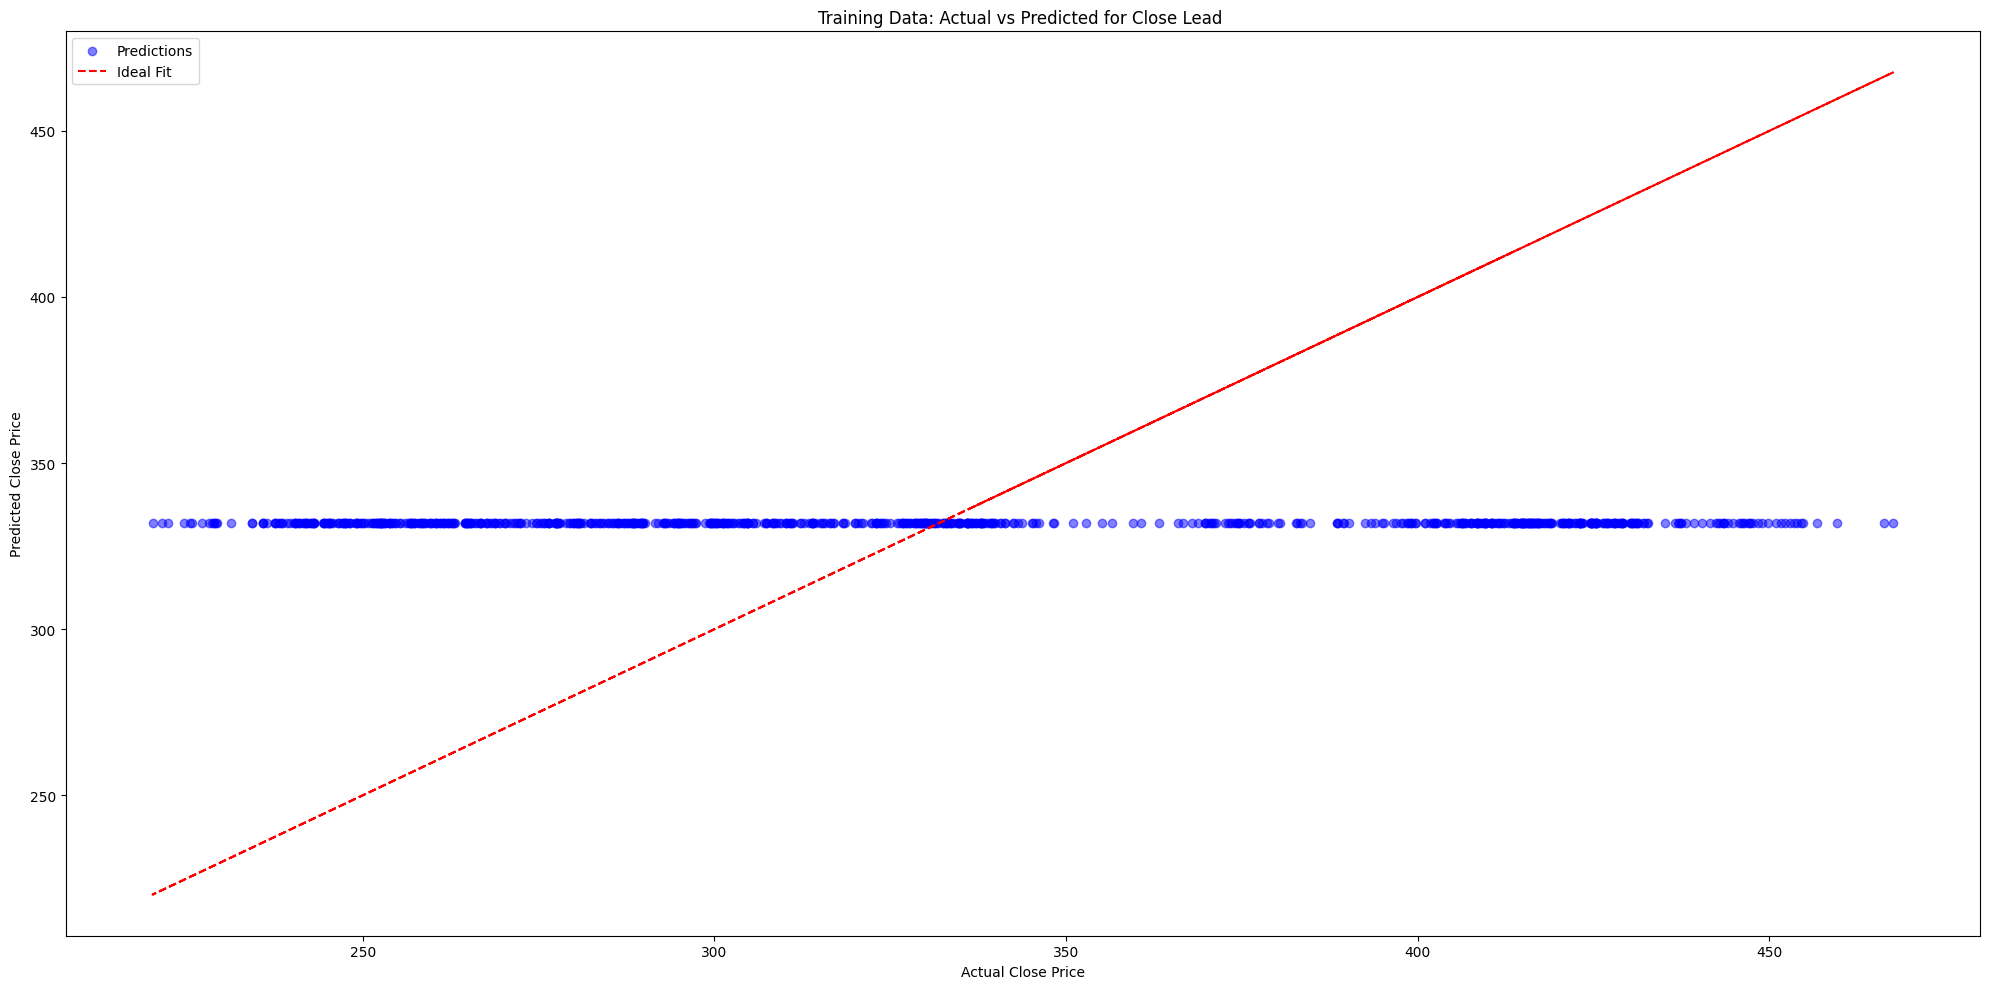

In [26]:
plt.figure(figsize=(20,10))
# for i in range(1,5):
# plt.subplot(2,2,i)
# scalerY.inverse_transform(y_train)
# plt.scatter(scalerY.inverse_transform(y_train), y_train_pred, alpha=0.5, color='blue', label="Predictions")
# plt.plot(scalerY.inverse_transform(y_train), scalerY.inverse_transform(y_train), color='red', linestyle='dashed', label="Ideal Fit")
plt.scatter(scalerY.inverse_transform(y_train), y_train_pred, alpha=0.5, color='blue', label="Predictions")
plt.plot(scalerY.inverse_transform(y_train), scalerY.inverse_transform(y_train), color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title(f"Training Data: Actual vs Predicted for Close Lead ")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
len(y_test)

196

In [15]:
y_test1=scalerY.inverse_transform(y_test)
y_test1.shape

(196, 4)

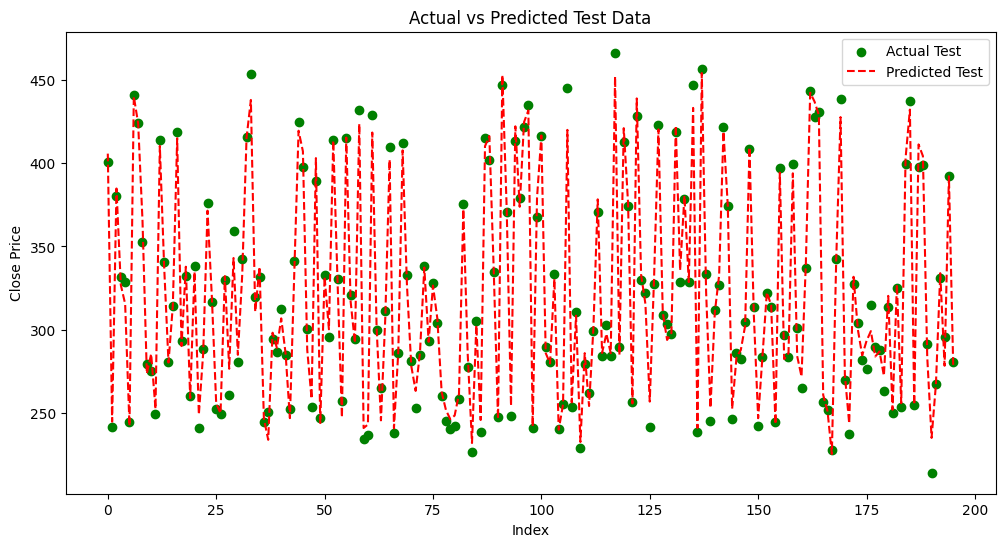

In [16]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(range(0,  len(y_test)), scalerY.inverse_transform(y_test)[:,0], label="Actual Test", color='green', linewidth=1)
plt.plot(range(0,  len(y_test)), y_test_pred[:,0], label="Predicted Test", color='red', linestyle='dashed')
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Test Data")
plt.legend()
plt.show()

In [17]:
X.shape

(980, 18)

(784, 18) (784, 4)
Test MAE: 0.12


ValueError: x and y must be the same size

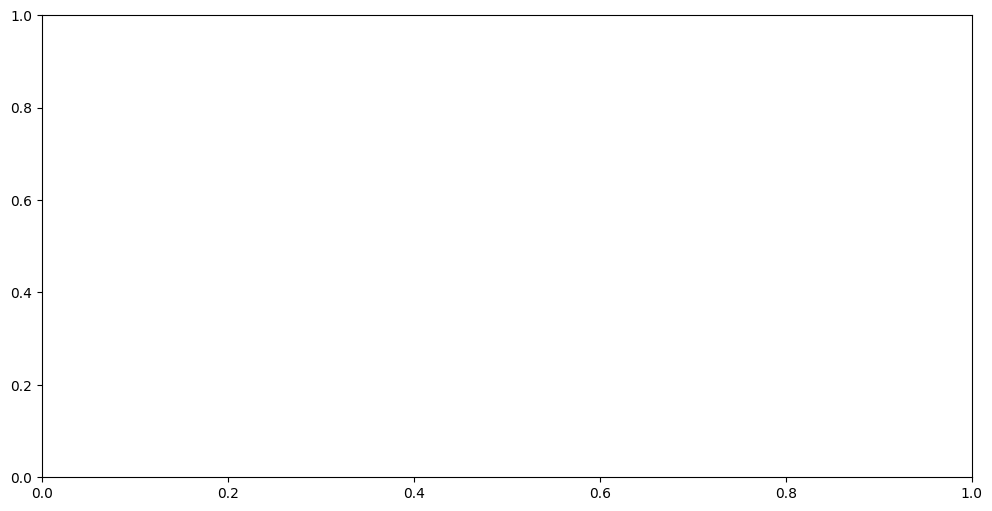

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
# Define Bagging Regressor with Decision Trees
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),  # Use 'estimator' instead of 'base_estimator'
    n_estimators=1,  
    max_samples=0.2,  
    bootstrap=True,   
    random_state=42
)
print(X_train.shape, y_train.shape)
# Train the model
bagging_model.fit(X_train, y_train)

# Get predictions
y_train_pred = bagging_model.predict(X_train)
y_test_pred = bagging_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_test_pred)
print(f"Test MAE: {mae:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
# plt.plot(range(len(y_train)), y_train, label="Actual Train", color='blue', linewidth=1)
# plt.plot(range(len(y_train)), y_train_pred, label="Predicted Train", color='cyan', linestyle='dashed')

plt.scatter(range(len(y_train), len(y_train) + len(y_test)), y_test, label="Actual Test", color='green', linewidth=1)
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test_pred, label="Predicted Test", color='red', linestyle='dashed')

plt.xlabel("Time Index")
plt.ylabel("Close Price")
plt.title("Bagging Model: Stock Close Price Prediction")
plt.legend()
plt.show()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue', label="Predictions")
plt.plot(y_train, y_train, color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Training Data: Actual vs Predicted")
plt.legend()

# Plot Testing Data
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green', label="Predictions")
plt.plot(y_test, y_test, color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Testing Data: Actual vs Predicted")
plt.legend()

plt.tight_layout()
plt.show()

2025-04-16 10:11:55.564146: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 10:11:55.578000: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744778515.591816   30933 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744778515.596519   30933 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744778515.607985   30933 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0122 - mae: 0.0843  
Test MAE: 0.08
Test Loss: 0.01
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


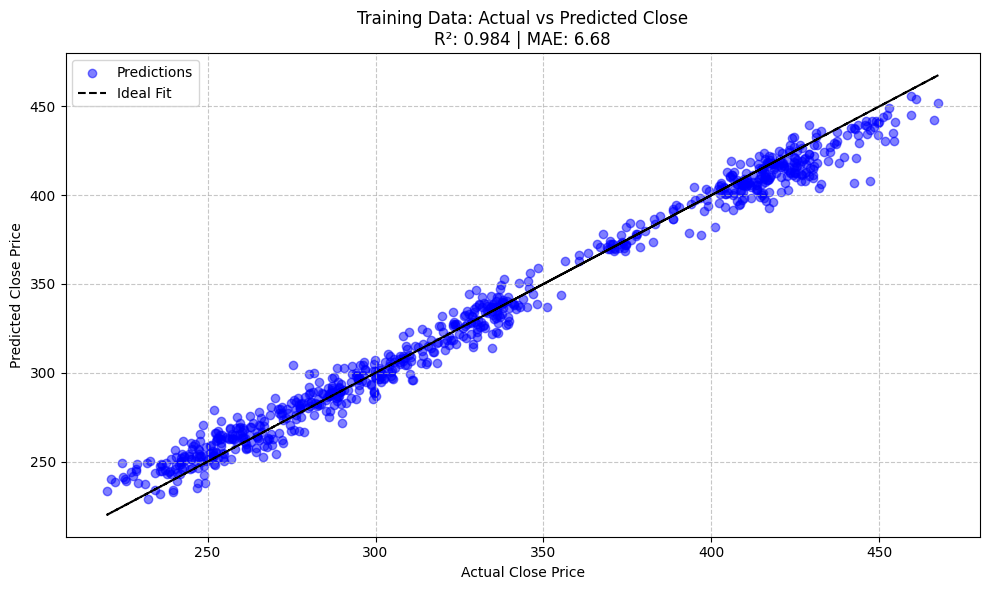

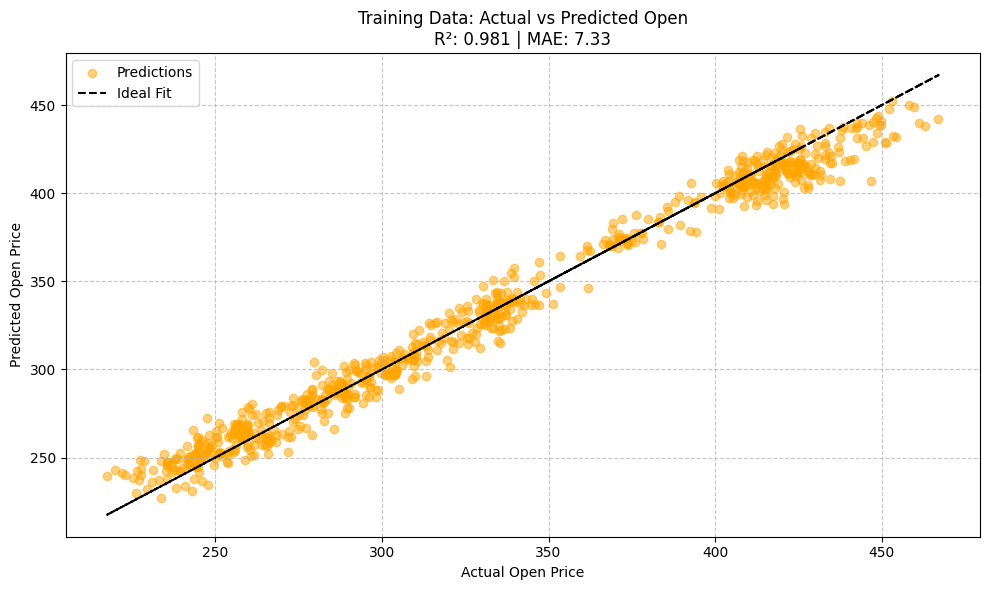

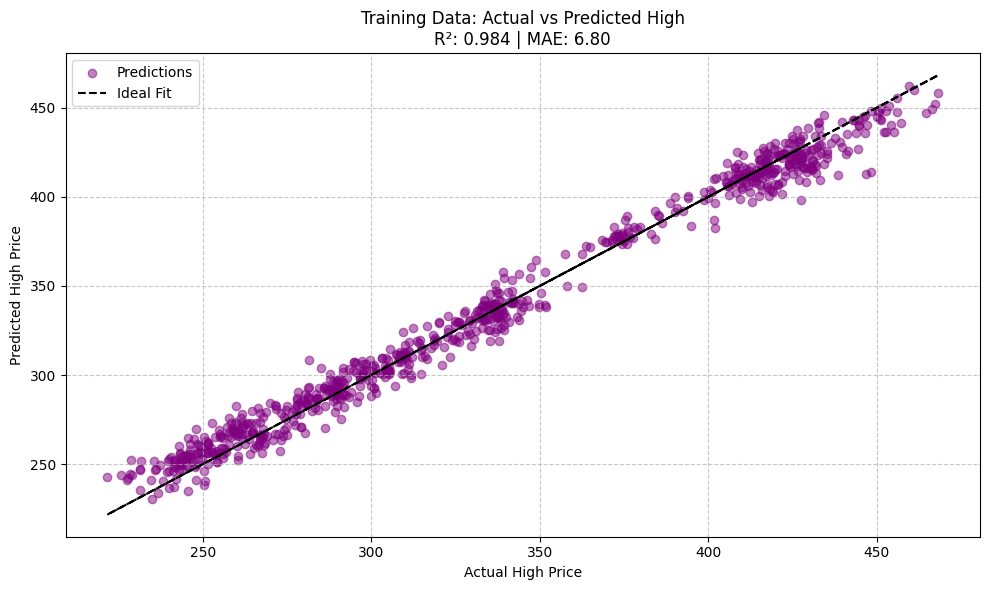

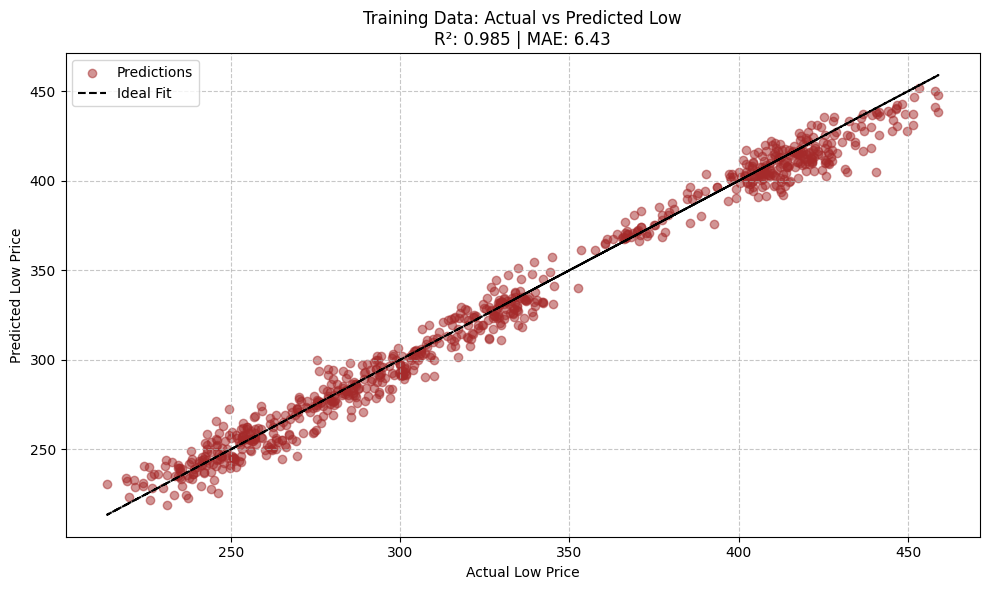

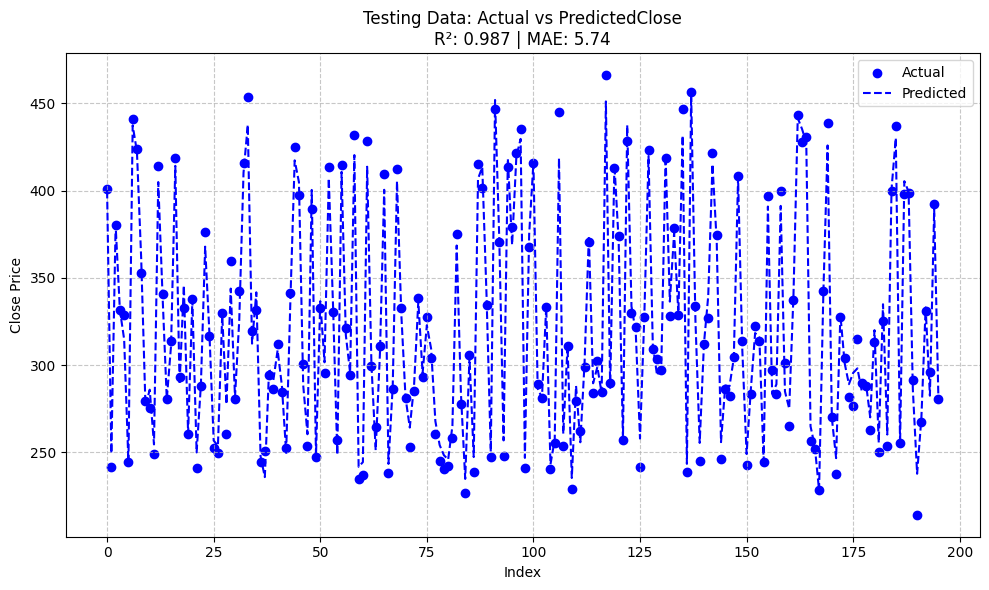

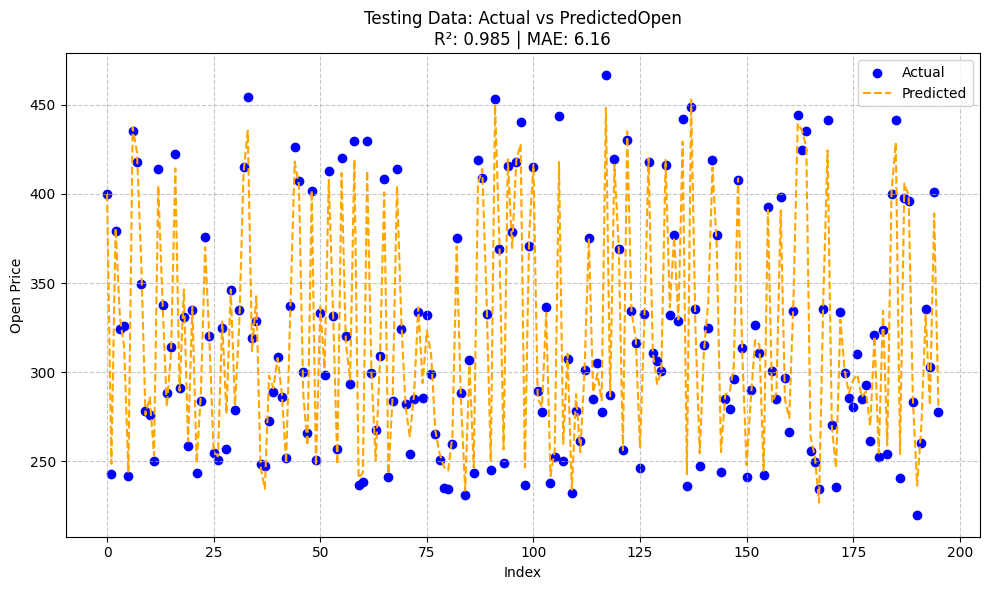

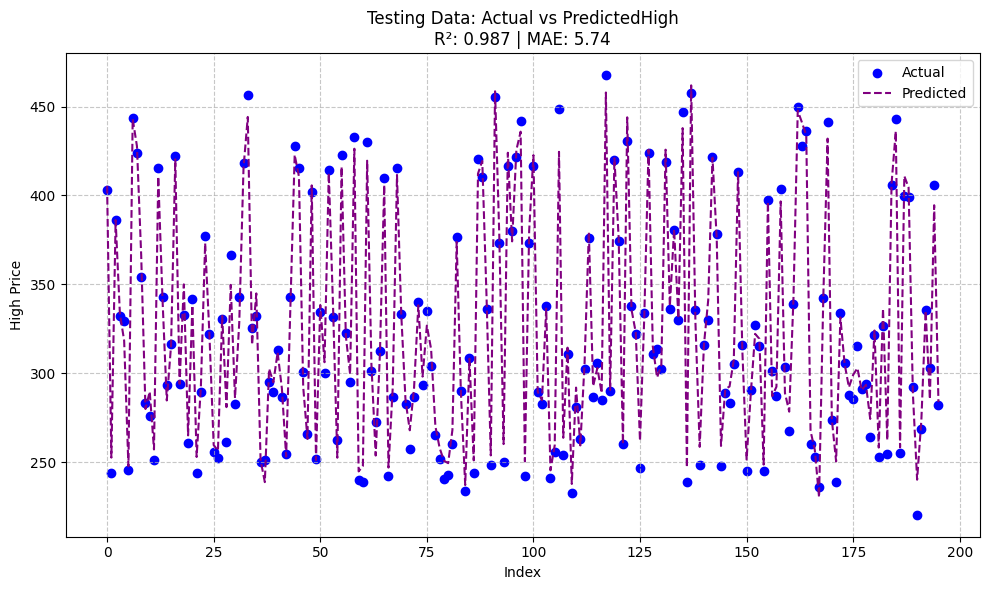

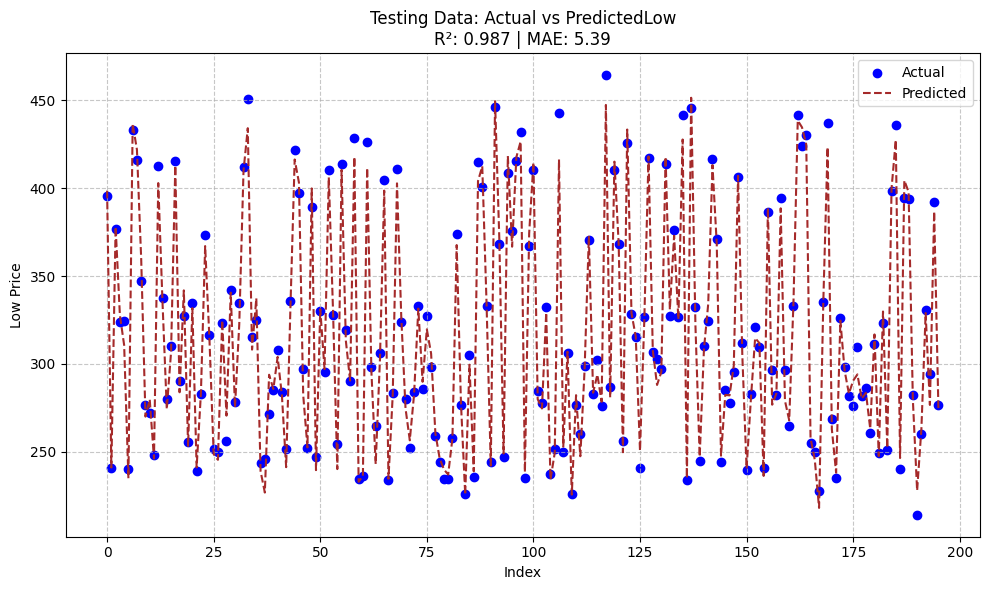

In [1]:
from NNmodel import StockPriceNN
regressor = StockPriceNN(stock_symbol="MSFT")
regressor.preprocess()
regressor.load_model()
# regressor.train(epochs=200)
regressor.evaluate()
regressor.plot_predictions()


In [1]:
from NNmodel import StockPriceNN
regressor = StockPriceNN(stock_symbol="MSFT")
model=regressor.load_model()

2025-04-16 10:07:36.071689: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 10:07:36.347977: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744778256.445386   27334 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744778256.474601   27334 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744778256.698972   27334 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [22]:
scalerX.inverse_transform(X_test)

array([[409.06, 399.04, 406.32, ..., 423.08, 420.99, 420.21],
       [241.22, 242.05, 245.03, ..., 252.51, 256.92, 257.22],
       [378.77, 388.56, 388.7 , ..., 373.11, 359.84, 357.86],
       ...,
       [278.91, 275.85, 288.5 , ..., 310.7 , 315.41, 313.86],
       [388.49, 388.61, 401.02, ..., 393.08, 395.16, 389.97],
       [274.82, 282.47, 283.65, ..., 276.44, 275.79, 278.85]])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


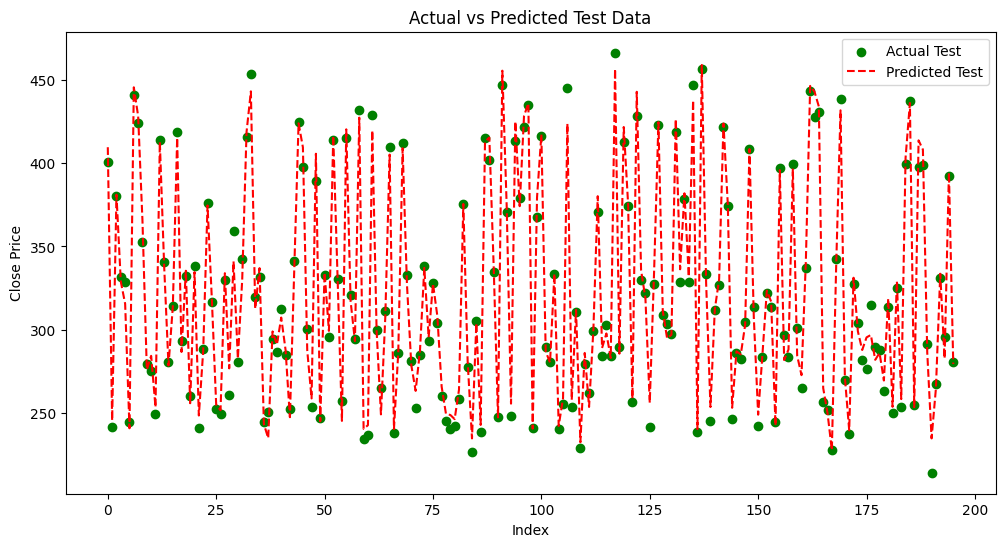

In [27]:
y_test_pred=regressor.predict(scalerX.inverse_transform(X_test))
y_test=y_test
plt.figure(figsize=(12, 6))
plt.scatter(range(0,  len(y_test)), scalerY.inverse_transform(y_test)[:,0], label="Actual Test", color='green', linewidth=1)
plt.plot(range(0,  len(y_test)), y_test_pred[:,0], label="Predicted Test", color='red', linestyle='dashed')
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Test Data")
plt.legend()
plt.show()

In [ ]:
y_train_pred = scalerY.inverse_transform(model.predict(X_train))
y_test_pred = scalerY.inverse_transform(model.predict(X_test))
y_train = y_train
y_test = y_test